# Eye-Tracking Reading Time Prediction

Experiment notebook for the Nitro NLP task. The goal is to predict word-level Total Reading Time (TRT, milliseconds) for unseen Romanian readers and texts, then write a submission CSV with `subtaskID`, `datapointID`, and `answer`.

The main modeling risk is leakage: test participants and texts are unseen. Validation therefore groups by `text` so each fold measures generalization to a held-out document.

## Setup

In [1]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
sns.set_theme(style='whitegrid', context='notebook')

RANDOM_STATE = 42
ROOT = Path('.')
TRAIN_PATH = ROOT / 'train_data.csv'
TEST_PATH = ROOT / 'test_data.csv'
SAMPLE_PATH = ROOT / 'sample_output.csv'
SUBMISSION_PATH = ROOT / 'submission.csv'

## Load Data

In [2]:
train = pd.read_csv(TRAIN_PATH, dtype={'participant_id': str})
test = pd.read_csv(TEST_PATH, dtype={'participant_id': str})
sample = pd.read_csv(SAMPLE_PATH)

expected_train = {'word_id', 'word', 'answer', 'participant_id', 'text'}
expected_test = {'word_id', 'word', 'participant_id', 'text', 'datapointID'}
expected_submission = {'subtaskID', 'datapointID', 'answer'}
assert set(train.columns) == expected_train
assert set(test.columns) == expected_test
assert set(sample.columns) == expected_submission

display(train.head())
display(test.head())
print(f'train rows: {len(train):,} | test rows: {len(test):,}')
print(f'train participants: {train.participant_id.nunique()} | test participants: {test.participant_id.nunique()}')
print(f'train texts: {train.text.nunique()} | test texts: {test.text.nunique()}')

,word_id,word,answer,participant_id,text
0,enc_wikimoon_13_page_1_0,Luna,0,028,enc_wikimoon
1,enc_wikimoon_13_page_1_1,https://ro.wikipedia.org/wiki/Luna,668,028,enc_wikimoon
2,enc_wikimoon_13_page_1_2,De,0,028,enc_wikimoon
3,enc_wikimoon_13_page_1_3,la,220,028,enc_wikimoon
4,enc_wikimoon_13_page_1_4,"Wikipedia,",0,028,enc_wikimoon


,word_id,word,participant_id,text,datapointID
0,arg_pisacowsmilk_10_page_1_0,Laptele,040,arg_pisacowsmilk,0
1,arg_pisacowsmilk_10_page_1_1,de,040,arg_pisacowsmilk,1
2,arg_pisacowsmilk_10_page_1_2,vacă,040,arg_pisacowsmilk,2
3,arg_pisacowsmilk_10_page_1_3,–,040,arg_pisacowsmilk,3
4,arg_pisacowsmilk_10_page_1_4,Introducere,040,arg_pisacowsmilk,4


train rows: 135,210 | test rows: 9,425
train participants: 30 | test participants: 5
train texts: 9 | test texts: 3


## Exploratory Analysis

TRT has a large skipped-word mass at zero and a long positive tail. The plots below check the target distribution, text and participant effects, and the basic relationship between word length and reading time.

In [3]:
summary = pd.DataFrame({
    'rows': [len(train), len(test)],
    'participants': [train.participant_id.nunique(), test.participant_id.nunique()],
    'texts': [train.text.nunique(), test.text.nunique()],
    'word_ids': [train.word_id.nunique(), test.word_id.nunique()],
}, index=['train', 'test'])
display(summary)

target_summary = train['answer'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).to_frame('answer')
target_summary.loc['zero_rate'] = (train['answer'].eq(0).mean())
display(target_summary)

,rows,participants,texts,word_ids
train,135210,30,9,4507
test,9425,5,3,1885


,answer
count,135210.000000
mean,264.440936
std,311.603579
min,0.000000
10%,0.000000
25%,0.000000
50%,200.000000
75%,367.000000
90%,612.000000
99%,1434.910000


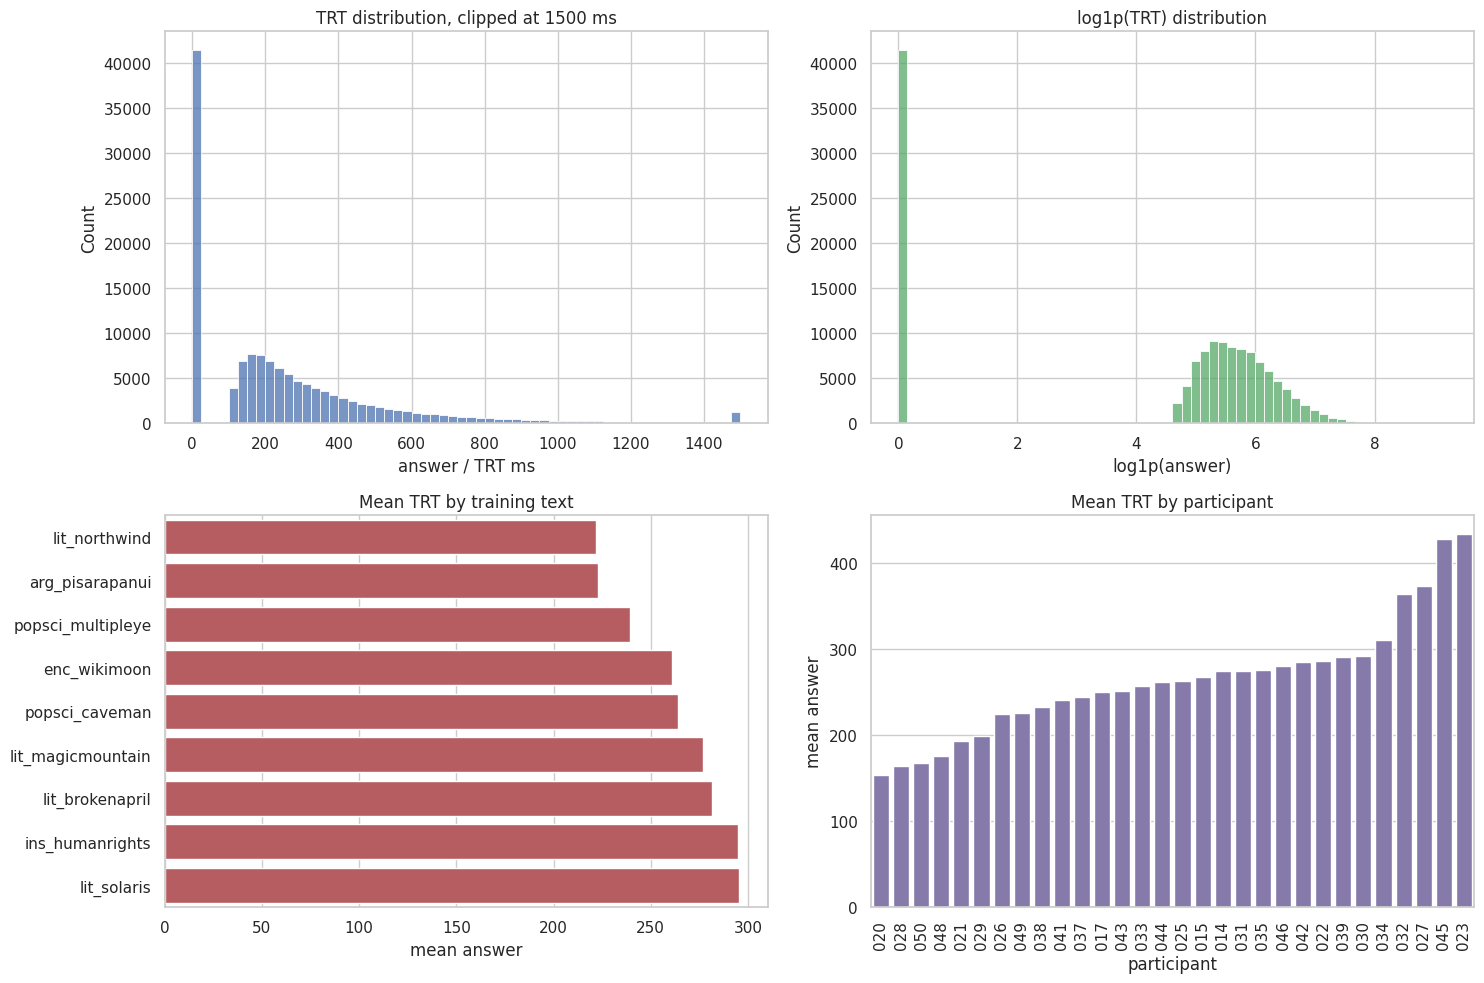

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(train['answer'].clip(upper=1500), bins=60, ax=axes[0, 0], color='#4C72B0')
axes[0, 0].set_title('TRT distribution, clipped at 1500 ms')
axes[0, 0].set_xlabel('answer / TRT ms')

sns.histplot(np.log1p(train['answer']), bins=60, ax=axes[0, 1], color='#55A868')
axes[0, 1].set_title('log1p(TRT) distribution')
axes[0, 1].set_xlabel('log1p(answer)')

text_stats = (train.groupby('text')['answer']
              .agg(mean_trt='mean', median_trt='median', zero_rate=lambda s: s.eq(0).mean())
              .reset_index()
              .sort_values('mean_trt'))
sns.barplot(data=text_stats, y='text', x='mean_trt', ax=axes[1, 0], color='#C44E52')
axes[1, 0].set_title('Mean TRT by training text')
axes[1, 0].set_xlabel('mean answer')
axes[1, 0].set_ylabel('')

participant_stats = train.groupby('participant_id')['answer'].mean().sort_values().reset_index()
sns.barplot(data=participant_stats, x='participant_id', y='answer', ax=axes[1, 1], color='#8172B2')
axes[1, 1].set_title('Mean TRT by participant')
axes[1, 1].set_xlabel('participant')
axes[1, 1].set_ylabel('mean answer')
axes[1, 1].tick_params(axis='x', rotation=90)

plt.tight_layout()

## Feature Engineering

Features are designed to transfer to unseen texts and participants: lexical shape, position parsed from `word_id`, broad text genre prefix, and corpus frequency statistics.

In [5]:
DIACRITICS = set('ăâîșşțţĂÂÎȘŞȚŢ')

def parse_word_id(series: pd.Series) -> pd.DataFrame:
    parsed = series.str.extract(r'(?P<doc>.+?)_(?P<section>\d+)_page_(?P<page>\d+)_(?P<word_pos>\d+)$')
    parsed['section'] = pd.to_numeric(parsed['section'], errors='coerce')
    parsed['page'] = pd.to_numeric(parsed['page'], errors='coerce')
    parsed['word_pos'] = pd.to_numeric(parsed['word_pos'], errors='coerce')
    return parsed

def build_base_features(df: pd.DataFrame, vocab_counts: pd.Series | None = None) -> pd.DataFrame:
    features = df.copy()
    features['word'] = features['word'].fillna('').astype(str)
    features['word_lower'] = features['word'].str.lower()
    features['genre'] = features['text'].str.split('_').str[0]
    features['word_len'] = features['word'].str.len()
    features['alpha_len'] = features['word'].str.count(r'[A-Za-zĂÂÎȘŞȚŢăâîșşțţ]')
    features['digit_count'] = features['word'].str.count(r'\d')
    features['punct_count'] = features['word'].str.count(r'[^\w\sĂÂÎȘŞȚŢăâîșşțţ]')
    features['diacritic_count'] = features['word'].apply(lambda value: sum(ch in DIACRITICS for ch in value))
    features['is_title'] = features['word'].str.istitle().astype(int)
    features['is_upper'] = features['word'].str.isupper().astype(int)
    features['has_digit'] = features['word'].str.contains(r'\d', regex=True).astype(int)
    features['has_url'] = features['word'].str.contains('http', case=False, regex=False).astype(int)
    features['has_diacritic'] = (features['diacritic_count'] > 0).astype(int)
    features['starts_sentence_like'] = features['is_title']

    parsed = parse_word_id(features['word_id'])
    features = pd.concat([features, parsed[['section', 'page', 'word_pos']]], axis=1)
    features['log_word_pos'] = np.log1p(features['word_pos'])
    features['word_pos_in_page_scaled'] = features.groupby('word_id')['word_pos'].transform('first')

    if vocab_counts is None:
        vocab_counts = features['word_lower'].value_counts()
    features['word_count_in_corpus'] = features['word_lower'].map(vocab_counts).fillna(0).astype(float)
    features['log_word_count_in_corpus'] = np.log1p(features['word_count_in_corpus'])
    return features

combined_counts = pd.concat([train['word'], test['word']], ignore_index=True).fillna('').astype(str).str.lower().value_counts()
train_fe = build_base_features(train, combined_counts)
test_fe = build_base_features(test, combined_counts)

display(train_fe[['word', 'word_lower', 'genre', 'word_len', 'word_pos', 'log_word_count_in_corpus', 'answer']].head())

,word,word_lower,genre,word_len,word_pos,log_word_count_in_corpus,answer
0,Luna,luna,enc,4,0,5.198497,0
1,https://ro.wikipedia.org/wiki/Luna,https://ro.wikipedia.org/wiki/luna,enc,34,1,3.433987,668
2,De,de,enc,2,2,8.860215,0
3,la,la,enc,2,3,7.368970,220
4,"Wikipedia,","wikipedia,",enc,10,4,3.433987,0


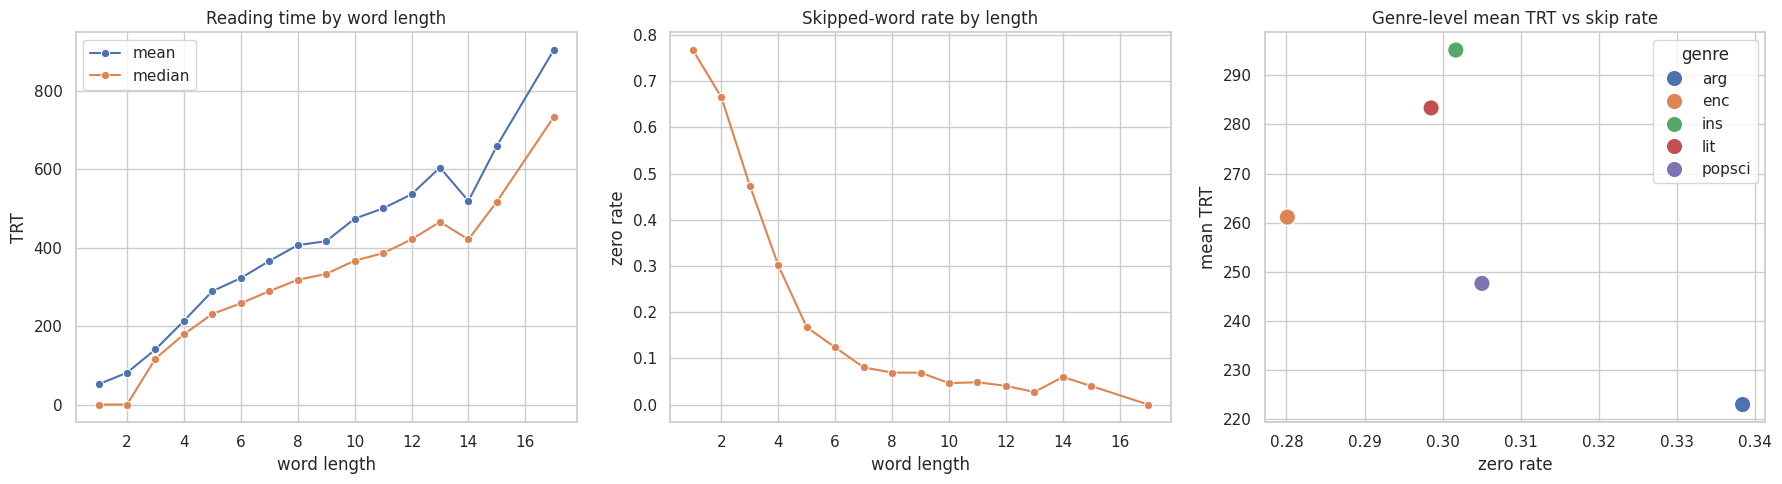

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

length_stats = train_fe.groupby('word_len')['answer'].agg(['mean', 'median', 'count']).reset_index()
length_stats = length_stats[length_stats['count'] >= 100]
sns.lineplot(data=length_stats, x='word_len', y='mean', marker='o', ax=axes[0], label='mean')
sns.lineplot(data=length_stats, x='word_len', y='median', marker='o', ax=axes[0], label='median')
axes[0].set_title('Reading time by word length')
axes[0].set_xlabel('word length')
axes[0].set_ylabel('TRT')

zero_by_len = train_fe.groupby('word_len')['answer'].apply(lambda s: s.eq(0).mean()).reset_index(name='zero_rate')
zero_by_len = zero_by_len.merge(length_stats[['word_len']], on='word_len')
sns.lineplot(data=zero_by_len, x='word_len', y='zero_rate', marker='o', ax=axes[1], color='#DD8452')
axes[1].set_title('Skipped-word rate by length')
axes[1].set_xlabel('word length')
axes[1].set_ylabel('zero rate')

genre_stats = train_fe.groupby('genre')['answer'].agg(mean='mean', zero_rate=lambda s: s.eq(0).mean()).reset_index()
sns.scatterplot(data=genre_stats, x='zero_rate', y='mean', hue='genre', s=140, ax=axes[2])
axes[2].set_title('Genre-level mean TRT vs skip rate')
axes[2].set_xlabel('zero rate')
axes[2].set_ylabel('mean TRT')

plt.tight_layout()

## Metric and Modeling Pipeline

Ridge with character n-gram TF-IDF is a strong baseline (`38.318` OOF). The final `solution.py` improves it with a GPU CatBoost direct regressor, a skip/positive two-stage CatBoost model, and the Ridge baseline blended with OOF calibration (`39.492` OOF).

In [7]:
def eval_metric(y_true, preds):
    y_true = np.asarray(y_true, dtype=float)
    preds = np.asarray(preds, dtype=float)
    r2 = r2_score(y_true, preds, force_finite=True)
    r2 = max(0.0, r2)
    pears = pearsonr(y_true, preds)[0]
    if np.isnan(pears):
        pears = 0.0
    return 100 * (abs(pears) + r2) / 2

numeric_features = [
    'word_len', 'alpha_len', 'digit_count', 'punct_count', 'diacritic_count',
    'is_title', 'is_upper', 'has_digit', 'has_url', 'has_diacritic',
    'section', 'page', 'word_pos', 'log_word_pos',
    'word_count_in_corpus', 'log_word_count_in_corpus',
]
categorical_features = ['genre']
text_feature = 'word_lower'

preprocess = ColumnTransformer(
    transformers=[
        ('word_chars', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), min_df=2, max_features=30000), text_feature),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler(with_mean=False)),
        ]), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ],
    remainder='drop',
)

model = Pipeline([
    ('features', preprocess),
    ('regressor', Ridge(alpha=300.0, random_state=RANDOM_STATE)),
])

## Validation by Held-Out Text

This validation is stricter than a random split because the official test set contains unseen texts.

In [8]:
X = train_fe[numeric_features + categorical_features + [text_feature]].copy()
y = train_fe['answer'].astype(float)
groups = train_fe['text']

fold_rows = []
oof = np.zeros(len(train_fe), dtype=float)
cv = GroupKFold(n_splits=train_fe['text'].nunique())

for fold, (fit_idx, valid_idx) in enumerate(cv.split(X, y, groups), start=1):
    heldout_text = groups.iloc[valid_idx].unique()[0]
    model.fit(X.iloc[fit_idx], y.iloc[fit_idx])
    preds = np.clip(model.predict(X.iloc[valid_idx]), 0, 10000)
    oof[valid_idx] = preds
    fold_rows.append({
        'fold': fold,
        'heldout_text': heldout_text,
        'rows': len(valid_idx),
        'metric': eval_metric(y.iloc[valid_idx], preds),
        'r2': r2_score(y.iloc[valid_idx], preds, force_finite=True),
        'pearson': pearsonr(y.iloc[valid_idx], preds)[0],
        'pred_mean': preds.mean(),
        'true_mean': y.iloc[valid_idx].mean(),
    })

fold_scores = pd.DataFrame(fold_rows).sort_values('metric', ascending=False)
display(fold_scores)
print(f'OOF metric: {eval_metric(y, oof):.3f}')
print(f'OOF R2: {r2_score(y, oof, force_finite=True):.4f}')
print(f'OOF Pearson: {pearsonr(y, oof)[0]:.4f}')

,fold,heldout_text,rows,metric,r2,pearson,pred_mean,true_mean
8,9,enc_wikimoon,3420,43.663731,0.297022,0.576253,316.513481,261.115205
0,1,lit_solaris,28080,39.516394,0.266210,0.524118,284.235336,295.529986
5,6,popsci_caveman,12660,39.433623,0.267026,0.521647,242.393144,264.286493
6,7,ins_humanrights,9540,39.352975,0.258621,0.528438,248.071649,295.142662
1,2,popsci_multipleye,24780,38.096555,0.237948,0.523983,287.698698,239.098547
2,3,arg_pisarapanui,20790,37.981432,0.244520,0.515109,243.556257,222.945214
4,5,lit_magicmountain,16170,37.271455,0.246243,0.499186,266.633886,277.028819
3,4,lit_brokenapril,16320,36.584867,0.238914,0.492784,283.826996,281.737868
7,8,lit_northwind,3450,31.680783,0.165670,0.467945,272.873364,221.630145


OOF metric: 38.318
OOF R2: 0.2580
OOF Pearson: 0.5083


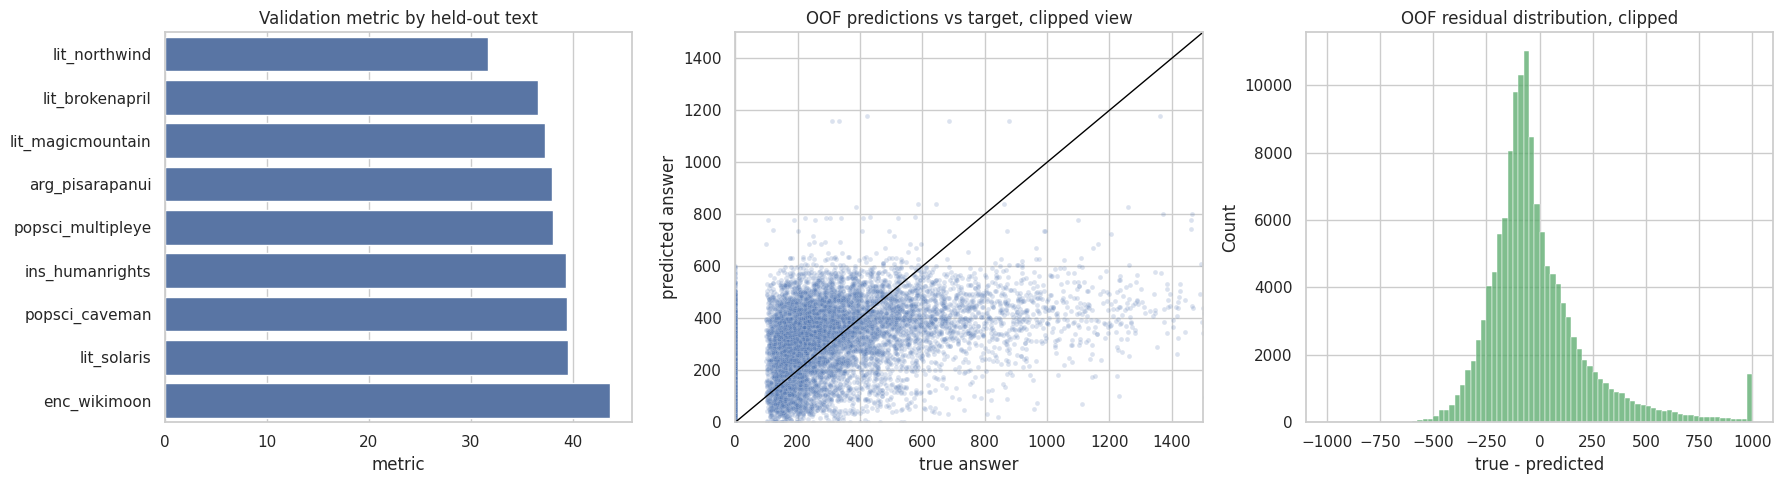

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=fold_scores.sort_values('metric'), y='heldout_text', x='metric', ax=axes[0], color='#4C72B0')
axes[0].set_title('Validation metric by held-out text')
axes[0].set_xlabel('metric')
axes[0].set_ylabel('')

sample_idx = np.random.default_rng(RANDOM_STATE).choice(len(y), size=min(12000, len(y)), replace=False)
sns.scatterplot(x=y.iloc[sample_idx], y=oof[sample_idx], alpha=0.2, s=12, ax=axes[1])
axes[1].plot([0, 1500], [0, 1500], color='black', linewidth=1)
axes[1].set_xlim(0, 1500)
axes[1].set_ylim(0, 1500)
axes[1].set_title('OOF predictions vs target, clipped view')
axes[1].set_xlabel('true answer')
axes[1].set_ylabel('predicted answer')

residuals = y - oof
sns.histplot(residuals.clip(-1000, 1000), bins=80, ax=axes[2], color='#55A868')
axes[2].set_title('OOF residual distribution, clipped')
axes[2].set_xlabel('true - predicted')

plt.tight_layout()

## Run GPU Ensemble and Write Submission

In [10]:
import subprocess
import sys

result = subprocess.run([sys.executable, 'solution.py'], check=True, capture_output=True, text=True)
print(result.stdout)

submission = pd.read_csv(SUBMISSION_PATH)
assert len(submission) == len(sample) == len(test)
assert submission['datapointID'].tolist() == sample['datapointID'].tolist()
assert submission['answer'].notna().all()

display(submission.head())
display(submission['answer'].describe().to_frame('predicted_answer'))
print(f'Wrote {SUBMISSION_PATH.resolve()}')

submission mean=275.959 std=175.787 max=1116.105
wrote /home/mihnea/Programming/Nitro NLP/submission.csv



,subtaskID,datapointID,answer
0,1,0,397.782695
1,1,1,30.006184
2,1,2,226.275453
3,1,3,0.000000
4,1,4,452.882138


,predicted_answer
count,9425.000000
mean,275.958759
std,175.786691
min,0.000000
25%,105.795016
50%,282.220903
75%,408.933504
max,1116.105388


Wrote /home/mihnea/Programming/Nitro NLP/submission.csv


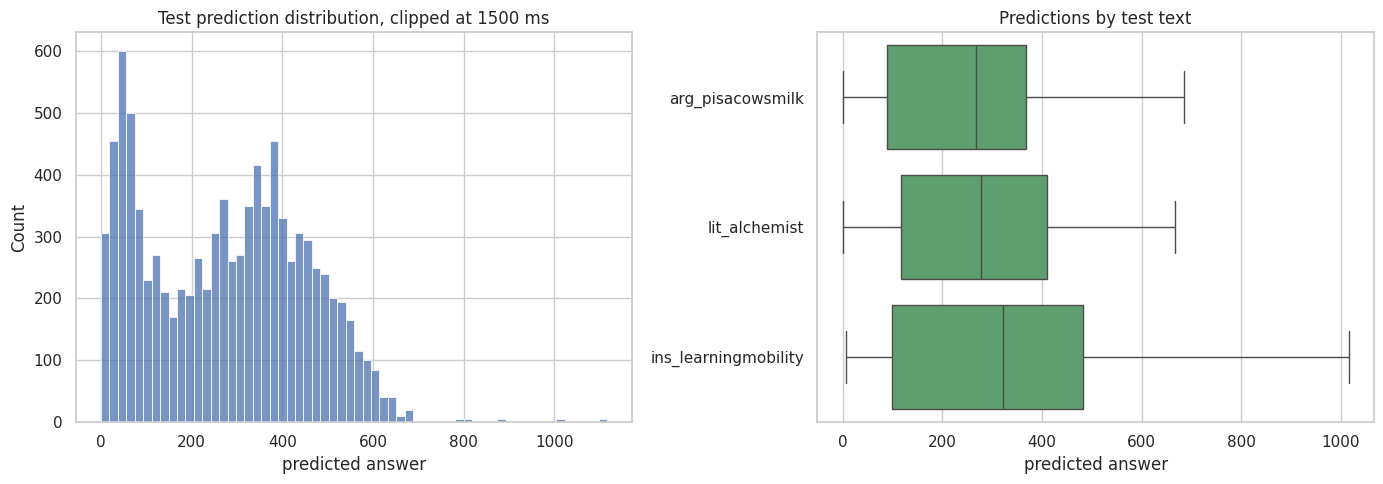

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(submission['answer'].clip(upper=1500), bins=60, ax=axes[0], color='#4C72B0')
axes[0].set_title('Test prediction distribution, clipped at 1500 ms')
axes[0].set_xlabel('predicted answer')

test_plot = test_fe[['text', 'genre']].copy()
test_plot['prediction'] = submission['answer'].values
sns.boxplot(data=test_plot, y='text', x='prediction', ax=axes[1], color='#55A868', showfliers=False)
axes[1].set_title('Predictions by test text')
axes[1].set_xlabel('predicted answer')
axes[1].set_ylabel('')

plt.tight_layout()

## Updated GPU Ensemble Result

EDA showed three durable signals: word length/shape, lexical frequency, and local context. Richer prefix/suffix features helped some held-out texts but hurt aggregate OOF, so the final submission keeps the more stable base features and improves by ensembling complementary models.

Final `solution.py` uses:

- GPU CatBoost direct TRT regressor.
- GPU CatBoost skip classifier times positive-only TRT regressor.
- Ridge character n-gram baseline.
- OOF-calibrated blend: `0.16 * direct + 0.52 * two_stage + 0.32 * ridge`, then affine calibration.

Validation improved from Ridge OOF `38.318` (`R2=0.2580`, `Pearson=0.5083`) to ensemble OOF `39.492` (`R2=0.2701`, `Pearson=0.5197`).

## Notes for Further Improvement

- Add external Romanian word frequency or language-model surprisal features if allowed.
- Tune blend weights per genre/text family only if validation remains grouped by held-out text.
- Test extra prefix/suffix/context categorical features carefully; they improved small folds but slightly hurt aggregate OOF.
- Consider participant normalization only if a public rule for unseen participants is available; raw participant IDs do not transfer to the official test participants.